In [1]:
%pprint
%load_ext supriya.ext.ipython

import warnings

warnings.filterwarnings(action="default", module="supriya")

from supriya.scsynth import kill

kill()

Pretty printing has been turned OFF


In [ ]:
# soundcheck

March 18th, 2025

# Supriya: a Python API for SuperCollider

Joséphine Wolf Oberholtzer (she / her)

## Introduction

- who am i
- what is supriya
- what isn't it
- what is this presentation
- what isn't this presentation
- what's in a name
- presentation overview

## Servers

### Import supriya

In [2]:
import supriya

In [ ]:
dir(supriya)

### Import `Server`

In [4]:
from supriya import Server

In [5]:
server = Server()

In [ ]:
dir(server)

### Server options

In [ ]:
server

In [ ]:
# TODO: Make Options a dataclass
server.options

### Boot the server

In [ ]:
server.boot()

### Inspect the server

In [ ]:
server.status

In [ ]:
print(tree := server.query_tree())

In [ ]:
tree

### Reset the server

In [ ]:
server.reset()

In [ ]:
print(tree := server.query_tree())

### Quit the server

In [ ]:
server.quit()

### Boot with options

In [ ]:
server.boot(maximum_logins=2)

### Multiple users

In [ ]:
other_server = Server()
other_server

In [ ]:
server

In [ ]:
other_server.connect()

In [ ]:
other_server.disconnect()

In [ ]:
server

### Lifecycle events

In [ ]:
def on_event(event):
    print(event)

for event_type in supriya.ServerLifecycleEvent:
    server.on(event_type, on_event)
    other_server.on(event_type, on_event)

In [ ]:
server.reboot()

In [ ]:
# this will panic
other_server.boot()

In [ ]:
server.quit()

## Entities

### Groups

In [9]:
server = Server().boot()

In [ ]:
# add a group
group = server.add_group()
print(group)
print(dir(group))
print(server.query_tree())

In [ ]:
# add a group to the group
child_group = group.add_group()
print(server.query_tree())

In [ ]:
# move the child group into the default group
child_group.move(target_node=server.default_group, add_action="ADD_TO_TAIL")
print(server.query_tree())

In [ ]:
# free the original parent group
group.free()
print(server.query_tree())

### Synths

In [ ]:
# add a synth (this will fail, silently)
synth = child_group.add_synth(synthdef=supriya.default)

In [ ]:
# we have a proxy to a synth
synth

In [ ]:
# but nothing on the server, because the request failed
print(server.query_tree())

In [ ]:
# using on_completion keyword argument
server.add_synthdefs(
    supriya.default,
    on_completion=lambda server: child_group.add_synth(synthdef=supriya.default),
) 
server.sync()
print(server.query_tree())

In [ ]:
# using completion context manager
with server.at():
    with server.add_synthdefs(supriya.default):
        synth = child_group.add_synth(synthdef=supriya.default, frequency=666)
server.sync()
print(server.query_tree())

In [ ]:
synth.set(frequency=555)

In [ ]:
synth.free()

In [ ]:
child_group.set(gate=0)

### Buses

- calculation rates
- allocate and free
- buses vs bus groups
- shared memory

### Buffers

- allocate and free
- read sound files
- generating
- plotting

## Messages

In [10]:
server.reset()

<Server ONLINE [/Applications/SuperCollider.app/Contents/Resources/scsynth -R 0 -l 1 -u 57110]>

In [ ]:
server.osc_protocol

In [ ]:
with server.osc_protocol.capture() as transcript:
    with server.at():
        with server.add_synthdefs(supriya.default):
            group = server.add_group()
            synth = group.add_synth(synthdef=supriya.default, frequency=666)

In [ ]:
for x in transcript: print(x)

### OSC messages & bundles

### Sending messages

In [ ]:
server.send([])

### OSC protocols

In [ ]:
server.osc_protocol

### Capturing IO

In [11]:
with server.osc_protocol.capture() as transcript:
    with server.at():
        group = server.add_group()
        with server.add_synthdefs(supriya.default):
            synth = group.add_synth(synthdef=supriya.default, frequency=666)
    server.sync()

In [12]:
for entry in transcript:
    print(entry)

CaptureEntry(timestamp=1736777971.919581, label='S', message=OscBundle(
    contents=(
        OscMessage('/g_new', 1000, 0, 1),
        OscMessage('/d_recv', b'SCgf\x00\x00\x00\x02\x00\x01\x07default\x00\x00\x00\x0c\x00\x00\x00\x00>\x99\x99\x9a<#\xd7\n?333@\x00\x00\x00\xbe\xcc\xcc\xcd>\xcc\xcc\xcdEz\x00\x00E\x9c@\x00E\x1c@\x00EH\x00\x00?\x80\x00\x00\x00\x00\x00\x05=\xcc\xcc\xcdC\xdc\x00\x00?\x80\x00\x00?\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x05\tamplitude\x00\x00\x00\x00\tfrequency\x00\x00\x00\x01\x04gate\x00\x00\x00\x02\x03pan\x00\x00\x00\x03\x03out\x00\x00\x00\x04\x00\x00\x00\x14\x07Control\x01\x00\x00\x00\x00\x00\x00\x00\x04\x00\x00\x01\x01\x01\x01\x06VarSaw\x02\x00\x00\x00\x03\x00\x00\x00\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x01\xff\xff\xff\xff\x00\x00\x00\x00\xff\xff\xff\xff\x00\x00\x00\x01\x02\x05Linen\x01\x00\x00\x00\x05\x00\x00\x00\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x02\xff\xff\xff\xff\x00\x00\x00\x02\xff\xff\xff\xff\x00\x00\x00\x03\xff\xff\xff\xff\x00\x00\x00\x01\x

### Moments & completions

### Requests & responses

## Synthdefs

### UGen methods

In [67]:
from supriya.ugens import SinOsc

SinOsc.ar()

<SinOsc.ar()[0]>

In [68]:
SinOsc.ar() * 4

<BinaryOpUGen.ar(MULTIPLICATION)[0]>

### Building SynthDefs

In [88]:
# A simple SynthDef using the builder pattern
from supriya.ugens import SynthDefBuilder
from supriya.ugens import Out, SinOsc

with SynthDefBuilder(freq=440, out=0) as builder:
    source = SinOsc.ar(frequency=builder["freq"])
    Out.ar(bus=builder["out"], source=[source, source])

simple_synthdef = builder.build(name="simple-synthdef")
simple_synthdef

<SynthDef: simple-synthdef>

In [47]:
r"""
*makeDefaultSynthDef {
    SynthDef(\default, { arg out=0, freq=440, amp=0.1, pan=0, gate=1;
        var z;
        z = LPF.ar(
            Mix.new(VarSaw.ar(freq + [0, Rand(-0.4,0.0), Rand(0.0,0.4)], 0, 0.3, 0.3)),
            XLine.kr(Rand(4000,5000), Rand(2500,3200), 1)
        ) * Linen.kr(gate, 0.01, 0.7, 0.3, 2);
        OffsetOut.ar(out, Pan2.ar(z, pan, amp));
    }, [\ir]).add;
}
"""

'\n*makeDefaultSynthDef {\n    SynthDef(\\default, { arg out=0, freq=440, amp=0.1, pan=0, gate=1;\n        var z;\n        z = LPF.ar(\n            Mix.new(VarSaw.ar(freq + [0, Rand(-0.4,0.0), Rand(0.0,0.4)], 0, 0.3, 0.3)),\n            XLine.kr(Rand(4000,5000), Rand(2500,3200), 1)\n        ) * Linen.kr(gate, 0.01, 0.7, 0.3, 2);\n        OffsetOut.ar(out, Pan2.ar(z, pan, amp));\n    }, [\\ir]).add;\n}\n'

In [48]:
# More imports
from supriya.enums import DoneAction, ParameterRate
from supriya.ugens import (
    LPF,
    Linen,
    Mix,
    OffsetOut,
    Pan2,
    Parameter,
    Rand,
    SynthDefBuilder,
    VarSaw,
    XLine,
)

In [49]:
# Define a builder
builder = SynthDefBuilder(
    out=Parameter(rate=ParameterRate.SCALAR, value=0),
    amplitude=0.1,
    frequency=440,
    gate=1,
    pan=0.5,
)

In [50]:
# Use the builder as a context manager
with builder:
    linen = Linen.kr(
        attack_time=0.01,
        done_action=DoneAction.FREE_SYNTH,
        gate=builder["gate"],
        release_time=0.3,
        sustain_level=0.7,
    )

In [51]:
# Use the builder again
with builder:
    low_pass = LPF.ar(
        source=Mix.new(
            VarSaw.ar(
                frequency=builder["frequency"]
                + (
                    0,
                    Rand.ir(minimum=-0.4, maximum=0.0),
                    Rand.ir(minimum=0.0, maximum=0.4),
                ),
                width=0.3,
            )
        )
        * 0.3,
        frequency=XLine.kr(
            start=Rand.ir(minimum=4000, maximum=5000),
            stop=Rand.ir(minimum=2500, maximum=3200),
        ),
    )

In [52]:
# And again and again
with builder:
    panner = Pan2.ar(
        source=low_pass * linen * builder["amplitude"], position=builder["pan"]
    )

with builder:
    OffsetOut.ar(bus=builder["out"], source=panner)

In [53]:
default = builder.build(name="default")
default

<SynthDef: default>

### `synthdef` decorator

In [23]:
# N.B. I'm not fond of this one because of a) how magical it is (not very, but just enough) but mainly because b) it makes type-checking difficult
from supriya.ugens import synthdef

In [57]:
@synthdef("ir")
def default_decorated(out=0, amplitude=0.1, frequency=440, gate=1, pan=0.5):
    linen = Linen.kr(
        attack_time=0.01,
        done_action=DoneAction.FREE_SYNTH,
        gate=gate,
        release_time=0.3,
        sustain_level=0.7,
    )
    low_pass = LPF.ar(
        source=Mix.new(
            VarSaw.ar(
                frequency=frequency
                + (
                    0,
                    Rand.ir(minimum=-0.4, maximum=0.0),
                    Rand.ir(minimum=0.0, maximum=0.4),
                ),
                width=0.3,
            )
        )
        * 0.3,
        frequency=XLine.kr(
            start=Rand.ir(minimum=4000, maximum=5000),
            stop=Rand.ir(minimum=2500, maximum=3200),
        ),
    )
    panner = Pan2.ar(
        source=low_pass * linen * amplitude, position=pan
    )
    _ = OffsetOut.ar(bus=out, source=panner)

<class 'supriya.ugens.core.Parameter'>


In [55]:
default_decorated

<SynthDef: default_decorated>

In [65]:
from supriya.ugens import Out, SinOsc

@synthdef()
def foo(out=0):
    print(repr(out))
    _ = Out.ar(source=SinOsc.kr())

foo

<Parameter.kr(out)>


<SynthDef: foo>

### Graphing SynthDefs

In [11]:
print(default)

synthdef:
    name: default
    ugens:
    -   Control.kr:
            amplitude: 0.1
            frequency: 440.0
            gate: 1.0
            pan: 0.5
    -   VarSaw.ar/0:
            frequency: Control.kr[1:frequency]
            initial_phase: 0.0
            width: 0.3
    -   Linen.kr:
            gate: Control.kr[2:gate]
            attack_time: 0.01
            sustain_level: 0.7
            release_time: 0.3
            done_action: 2.0
    -   Control.ir:
            out: 0.0
    -   Rand.ir/0:
            minimum: -0.4
            maximum: 0.0
    -   BinaryOpUGen(ADDITION).kr/0:
            left: Control.kr[1:frequency]
            right: Rand.ir/0[0]
    -   VarSaw.ar/1:
            frequency: BinaryOpUGen(ADDITION).kr/0[0]
            initial_phase: 0.0
            width: 0.3
    -   Rand.ir/1:
            minimum: 0.0
            maximum: 0.4
    -   BinaryOpUGen(ADDITION).kr/1:
            left: Control.kr[1:frequency]
            right: Rand.ir/1[0]
    -   VarSaw

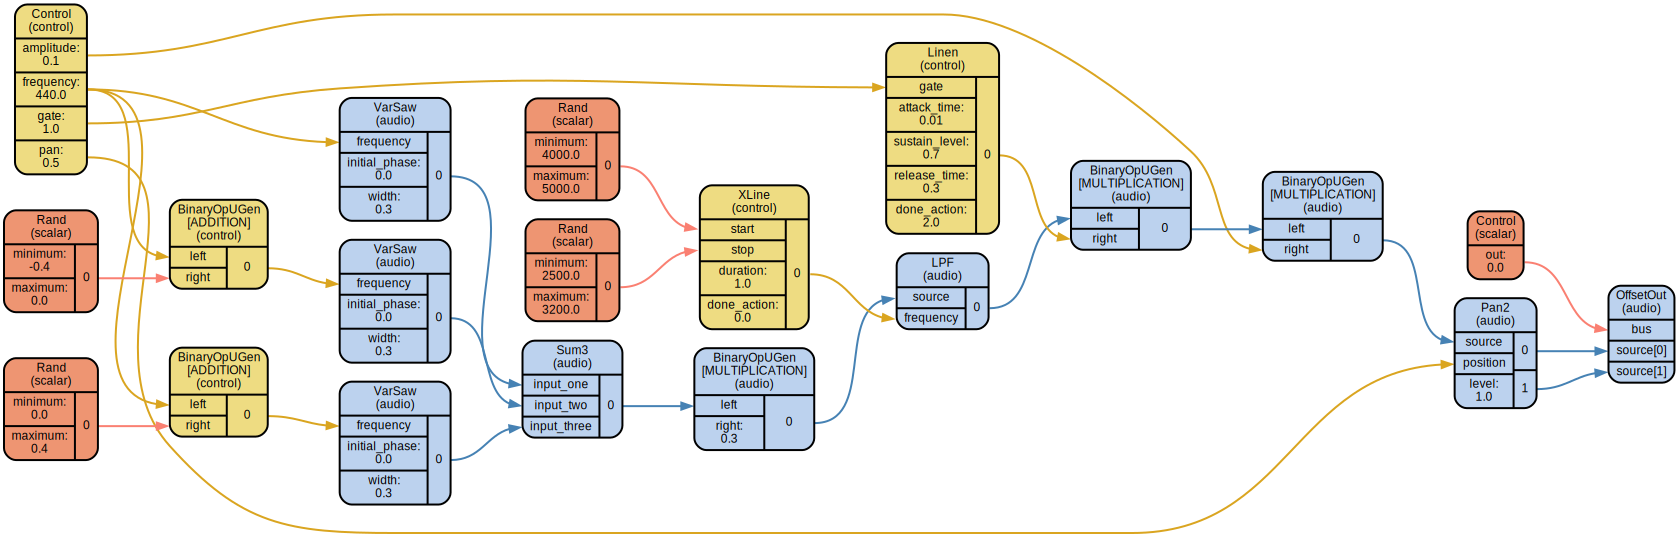

In [10]:
from supriya import graph

_ = graph(default)

### SynthDef internals

In [33]:
dir(default)

['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__firstlineno__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__graph__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__static_attributes__', '__str__', '__subclasshook__', '__weakref__', '_collect_indexed_parameters', '_compiled_graph', '_constants', '_controls', '_name', '_parameters', '_ugens', 'anonymous_name', 'compile', 'constants', 'controls', 'effective_name', 'has_gate', 'indexed_parameters', 'name', 'parameters', 'ugens']

In [28]:
default.name

'default'

In [29]:
default.anonymous_name

'7b802826ce5d2f89bab1a5a5eb1b1de1'

In [40]:
default.effective_name

'default'

In [30]:
default.parameters

mappingproxy({'amplitude': (<Parameter.kr(amplitude)>, 0), 'frequency': (<Parameter.kr(frequency)>, 1), 'gate': (<Parameter.kr(gate)>, 2), 'pan': (<Parameter.kr(pan)>, 3), 'out': (<Parameter.ir(out)>, 4)})

In [31]:
default.ugens

(<Control.kr()>, <Linen.kr()>, <VarSaw.ar()>, <Control.ir()>, <Rand.ir()>, <BinaryOpUGen.kr(ADDITION)>, <VarSaw.ar()>, <Rand.ir()>, <BinaryOpUGen.kr(ADDITION)>, <VarSaw.ar()>, <Sum3.ar()>, <BinaryOpUGen.ar(MULTIPLICATION)>, <Rand.ir()>, <Rand.ir()>, <XLine.kr()>, <LPF.ar()>, <BinaryOpUGen.ar(MULTIPLICATION)>, <BinaryOpUGen.ar(MULTIPLICATION)>, <Pan2.ar()>, <OffsetOut.ar()>)

In [32]:
default.has_gate

True

### SynthDef (de)compilation

In [35]:
compiled = default.compile()
compiled

b'SCgf\x00\x00\x00\x02\x00\x01\x07default\x00\x00\x00\x0c<#\xd7\n?333>\x99\x99\x9a@\x00\x00\x00\x00\x00\x00\x00\xbe\xcc\xcc\xcd>\xcc\xcc\xcdEz\x00\x00E\x9c@\x00E\x1c@\x00EH\x00\x00?\x80\x00\x00\x00\x00\x00\x05=\xcc\xcc\xcdC\xdc\x00\x00?\x80\x00\x00?\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x05\tamplitude\x00\x00\x00\x00\tfrequency\x00\x00\x00\x01\x04gate\x00\x00\x00\x02\x03pan\x00\x00\x00\x03\x03out\x00\x00\x00\x04\x00\x00\x00\x14\x07Control\x01\x00\x00\x00\x00\x00\x00\x00\x04\x00\x00\x01\x01\x01\x01\x05Linen\x01\x00\x00\x00\x05\x00\x00\x00\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x02\xff\xff\xff\xff\x00\x00\x00\x00\xff\xff\xff\xff\x00\x00\x00\x01\xff\xff\xff\xff\x00\x00\x00\x02\xff\xff\xff\xff\x00\x00\x00\x03\x01\x06VarSaw\x02\x00\x00\x00\x03\x00\x00\x00\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x01\xff\xff\xff\xff\x00\x00\x00\x04\xff\xff\xff\xff\x00\x00\x00\x02\x02\x07Control\x00\x00\x00\x00\x00\x00\x00\x00\x01\x00\x04\x00\x04Rand\x00\x00\x00\x00\x02\x00\x00\x00\x01\x00\x00\xff\xff\xff\x

In [38]:
from supriya.ugens import decompile_synthdef

decompiled = decompile_synthdef(compiled)
decompiled

<SynthDef: default>

In [39]:
default is decompiled

False

In [42]:
from supriya.ugens import SuperColliderSynthDef

sc_synthdef = SuperColliderSynthDef(
    "foo", "Out.ar(0, SinOsc.ar(freq: 420) * SinOsc.ar(freq: 440))"
)
sc_compiled_synthdef = sc_synthdef.compile()
sc_compiled_synthdef

compiling class library...
	Found 855 primitives.
	Compiling directory '/Applications/SuperCollider.app/Contents/Resources/SCClassLibrary'
	Compiling directory '/Users/josephine/Library/Application Support/SuperCollider/Extensions'
	numentries = 939044 / 14493240 = 0.065
	5706 method selectors, 2540 classes
	method table size 15170976 bytes, big table size 115945920
	Number of Symbols 13189
	Byte Code Size 406110
	compiled 409 files in 0.81 seconds
compile done
localhost : setting clientID to 0.
internal : setting clientID to 0.
Class tree inited in 0.01 seconds


*** Welcome to SuperCollider 3.13.0. *** For help type cmd-d.
Defined SynthDef
Wrote SynthDef
cleaning up OSC


b'SCgf\x00\x00\x00\x02\x00\x01\x03foo\x00\x00\x00\x03C\xd2\x00\x00\x00\x00\x00\x00C\xdc\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x04\x06SinOsc\x02\x00\x00\x00\x02\x00\x00\x00\x01\x00\x00\xff\xff\xff\xff\x00\x00\x00\x00\xff\xff\xff\xff\x00\x00\x00\x01\x02\x06SinOsc\x02\x00\x00\x00\x02\x00\x00\x00\x01\x00\x00\xff\xff\xff\xff\x00\x00\x00\x02\xff\xff\xff\xff\x00\x00\x00\x01\x02\x0cBinaryOpUGen\x02\x00\x00\x00\x02\x00\x00\x00\x01\x00\x02\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x01\x00\x00\x00\x00\x02\x03Out\x02\x00\x00\x00\x02\x00\x00\x00\x00\x00\x00\xff\xff\xff\xff\x00\x00\x00\x01\x00\x00\x00\x02\x00\x00\x00\x00\x00\x00'

In [44]:
print(decompile_synthdef(sc_compiled_synthdef))

synthdef:
    name: foo
    ugens:
    -   SinOsc.ar/0:
            frequency: 420.0
            phase: 0.0
    -   SinOsc.ar/1:
            frequency: 440.0
            phase: 0.0
    -   BinaryOpUGen(MULTIPLICATION).ar:
            left: SinOsc.ar/0[0]
            right: SinOsc.ar/1[0]
    -   Out.ar:
            bus: 0.0
            source[0]: BinaryOpUGen(MULTIPLICATION).ar[0]


### UGen metaprogramming

In [74]:
from supriya.ugens import UGen, param, ugen

# A dupe of SinOsc
@ugen(ar=True, kr=True, is_pure=True)
class AnotherSinOsc(UGen):
    frequency = param(440.0)
    phase = param(0.0)

In [75]:
AnotherSinOsc.ar()

<AnotherSinOsc.ar()[0]>

In [76]:
AnotherSinOsc.kr()

<AnotherSinOsc.kr()[0]>

In [84]:
# This won't work because ir=True wasn't set
AnotherSinOsc.ir()

AttributeError: type object 'AnotherSinOsc' has no attribute 'ir'

In [83]:
# A dupe of Out
@ugen(ar=True, kr=True, is_output=True, channel_count=0, fixed_channel_count=True)
class AnotherOut(UGen):
    bus = param(0)
    source = param(unexpanded=True)

AnotherOut.ar(source=AnotherSinOsc.ar())

<AnotherOut.ar()>

In [82]:
from supriya.ugens.pv import PV_ChainUGen

# A dupe of PV_BinShift
@ugen(kr=True, is_width_first=True)
class AnotherPV_BinShift(PV_ChainUGen):
    pv_chain = param()
    stretch = param(1.0)
    shift = param(0.0)
    interpolate = param(0)

# This won't work because of missing pv_chain argument
AnotherPV_BinShift.kr()

TypeError: AnotherPV_BinShift.kr() missing 1 required keyword-only argument: 'pv_chain'

In [ ]:
"""
def ugen(
    *,
    ar: bool = False,
    kr: bool = False,
    ir: bool = False,
    dr: bool = False,
    new: bool = False,
    has_done_flag: bool = False,
    is_input: bool = False,
    is_multichannel: bool = False,
    is_output: bool = False,
    is_pure: bool = False,
    is_width_first: bool = False,
    channel_count: int = 1,
    fixed_channel_count: bool = False,
    signal_range: Optional[int] = None,
) -> Callable[[Type["UGen"]], Type["UGen"]]:
    ...
"""

## Clocks & Patterns

## Non-Realtime

- server
- session
- mutations vs queries
- rendering (async)

## Concurrency

- server
- async server
- threaded concurrency
- event loop / coroutine concurrency

## Mixers

## Cleanliness

- docs
- typing
- testing
- ci/cd